# 01b — Advanced Image Processing for Radiomics

**Objective:** Deconstruct the "black box" of automated feature extraction by manually implementing and visualizing key image processing steps.

**Learning Outcomes:**
1. **Intensity Normalization:** Implement and compare Z-score vs. Min-Max normalization.
2. **Discretization (Binning):** Visualize how `binWidth` affects image histograms and texture granularity.
3. **Filtering:** Manually apply and visualize Laplacian of Gaussian (LoG) and Wavelet transforms.
4. **Resampling:** Understand the impact of interpolation kernels on image texture.

**Time:** ~60-90 minutes

In [24]:
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import seaborn as sns
import radiomics
from radiomics import imageoperations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 1. Load Data
We will use the PyRadiomics 'brain1' test case for this exercise.

In [25]:
image_path, mask_path = radiomics.getTestCase('brain1')
img_sitk = sitk.ReadImage(image_path)
mask_sitk = sitk.ReadImage(mask_path)

img_array = sitk.GetArrayFromImage(img_sitk)
mask_array = sitk.GetArrayFromImage(mask_sitk)

# Find central slice of the tumor
z_slice = np.argmax(np.sum(mask_array, axis=(1, 2)))
tumor_slice = img_array[z_slice]
tumor_mask = mask_array[z_slice]

print(f"Target slice: {z_slice}")

Target slice: 16


## 2. Intensity Normalization
Radiomics features (especially first-order) are highly sensitive to the intensity scale. 

### Task: Implement Z-score Normalization
Formula: $I_{norm} = \frac{I - \mu}{\sigma}$

**Question for students:** Why do we typically normalize *only* the pixels within the mask (or a specific range) rather than the whole image (which includes air/background)?

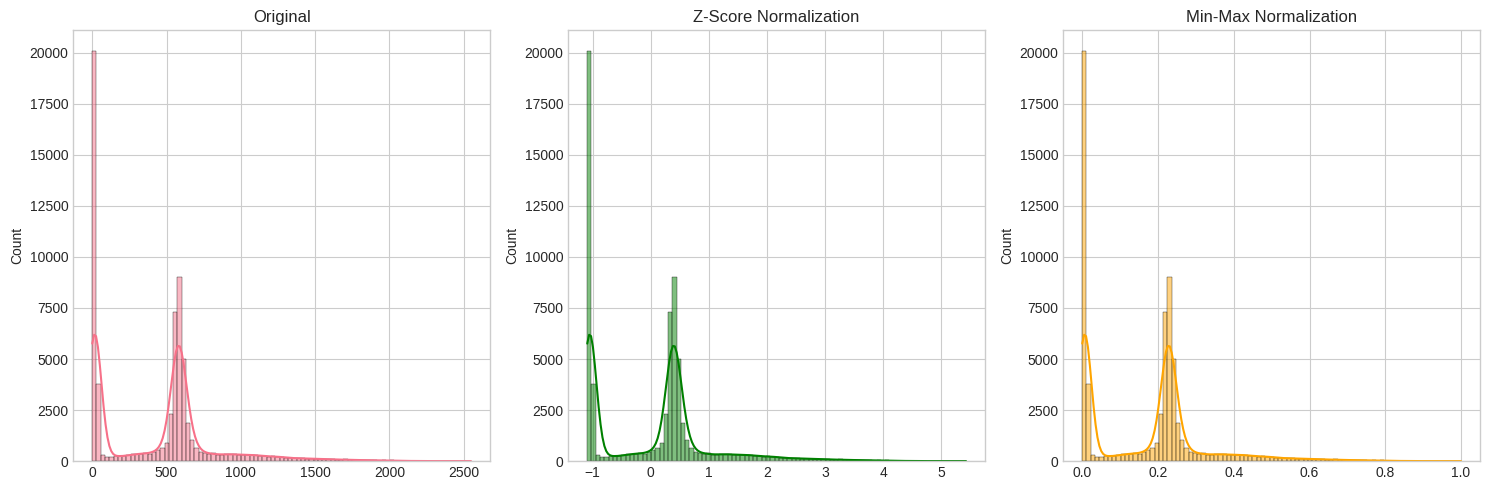

In [26]:
def normalize_zscore(array):
    return (array - np.mean(array)) / np.std(array)

def normalize_minmax(array):
    return (array - np.min(array)) / (np.max(array) - np.min(array))

img_z = normalize_zscore(tumor_slice)
img_mm = normalize_minmax(tumor_slice)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title("Original")
sns.histplot(tumor_slice.ravel(), ax=axes[0], kde=True)

axes[1].set_title("Z-Score Normalization")
sns.histplot(img_z.ravel(), ax=axes[1], kde=True, color='green')

axes[2].set_title("Min-Max Normalization")
sns.histplot(img_mm.ravel(), ax=axes[2], kde=True, color='orange')

plt.tight_layout()
plt.show()

## 3. Discretization (Gray-Level Binning)
Texture matrices (GLCM, GLRLM) require discrete values. `binWidth` is a critical parameter.

### Task: Visualize Binning Impact
Compare a small `binWidth` (many bins) vs. a large `binWidth` (few bins).

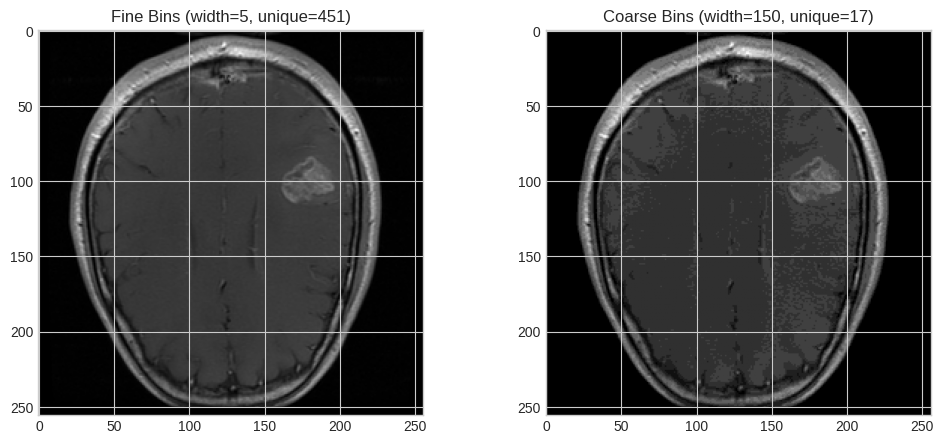

Notice how coarse binning removes subtle texture variations.


In [32]:
def apply_binning(image, bin_width):
    # Simple binning logic: floor( (I - min) / binWidth )
    minimum = np.min(image)
    return np.floor((image - minimum) / bin_width).astype(int)

bins_small = apply_binning(tumor_slice, 5)
bins_large = apply_binning(tumor_slice, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_title(f"Fine Bins (width=5, unique={len(np.unique(bins_small))})")
axes[0].imshow(bins_small, cmap='gray')
axes[1].set_title(f"Coarse Bins (width=150, unique={len(np.unique(bins_large))})")
axes[1].imshow(bins_large, cmap='gray')
plt.show()

print("Notice how coarse binning removes subtle texture variations.")

## 4. Advanced Filtering: Laplacian of Gaussian (LoG)
LoG is an edge-enhancement filter. The parameter $\sigma$ controls the scale of the edges detected.

### Task: Compare LoG Scales
Visualizing $\sigma=1.0$ (fine detail) vs. $\sigma=5.0$ (coarse structure).

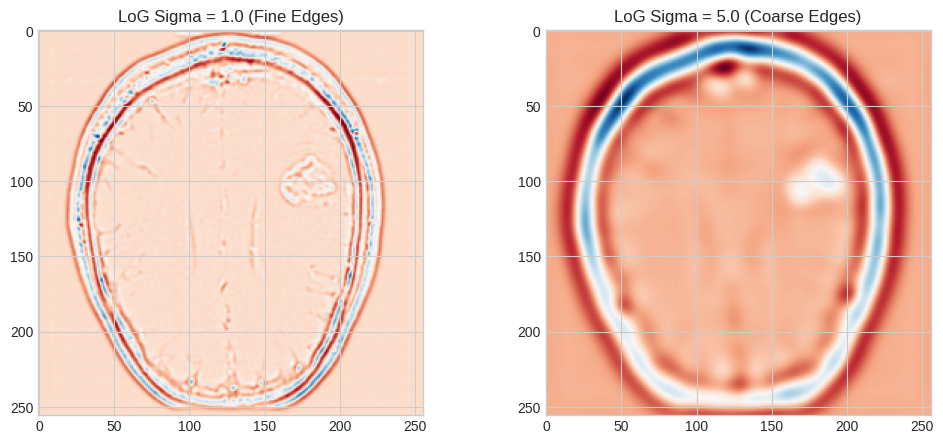

In [33]:
def get_log_filter(image_sitk, sigma):
    log_img = sitk.LaplacianRecursiveGaussian(image_sitk, sigma)
    return sitk.GetArrayFromImage(log_img)

log_fine = get_log_filter(img_sitk, 1.0)[z_slice]
log_coarse = get_log_filter(img_sitk, 5.0)[z_slice]

fig, axes = plt.subplhots(1, 2, figsize=(12, 5))
axes[0].set_title("LoG Sigma = 1.0 (Fine Edges)")
axes[0].imshow(log_fine, cmap='RdBu_r')
axes[1].set_title("LoG Sigma = 5.0 (Coarse Edges)")
axes[1].imshow(log_coarse, cmap='RdBu_r')
plt.show()

## 5. Wavelet Decompositions
Wavelets decompose the image into low and high-frequency components (LLH, LHL, etc.).

### Task: Visualize a Wavelet Band
Students should observe how different bands highlight horizontal, vertical, or diagonal edges.

INFO:radiomics.imageoperations:Computing Wavelet LLH
INFO:radiomics.imageoperations:Computing Wavelet LHL
INFO:radiomics.imageoperations:Computing Wavelet LHH
INFO:radiomics.imageoperations:Computing Wavelet HLL
INFO:radiomics.imageoperations:Computing Wavelet HLH
INFO:radiomics.imageoperations:Computing Wavelet HHL
INFO:radiomics.imageoperations:Computing Wavelet HHH


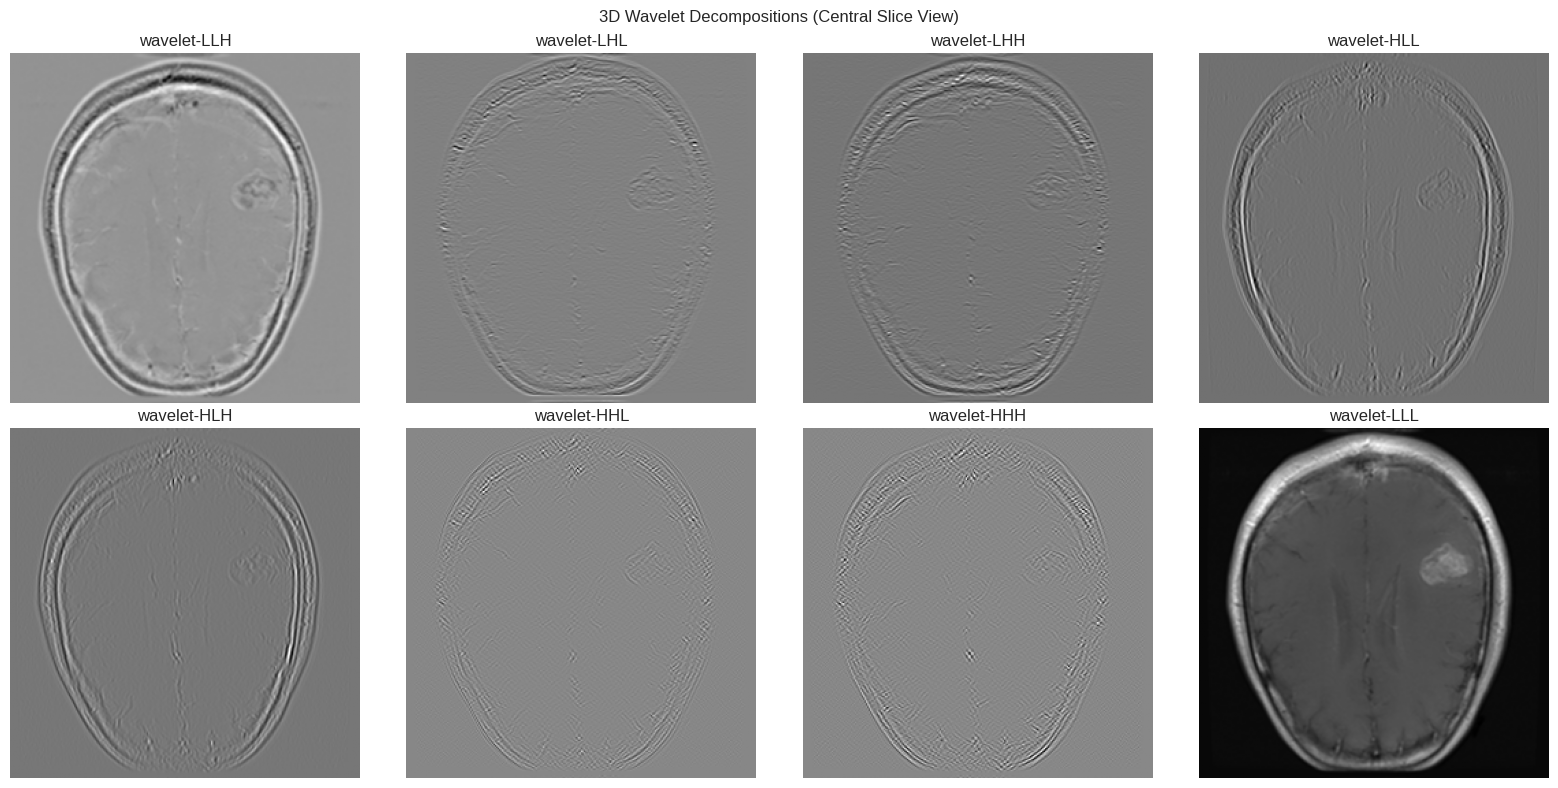

In [34]:
# Use PyRadiomics imageoperations to get wavelet decompositions
wavelets = list(imageoperations.getWaveletImage(img_sitk, mask_sitk))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, (w_img, w_name, w_args) in enumerate(wavelets):
    w_arr = sitk.GetArrayFromImage(w_img)[z_slice]
    axes[i].set_title(w_name)
    axes[i].imshow(w_arr, cmap='gray')
    axes[i].axis('off')

plt.suptitle("3D Wavelet Decompositions (Central Slice View)")
plt.tight_layout()
plt.show()

## 6. Challenge: The Impact on Features

**Experimental Task:**
1. Take the `tumor_slice`.
2. Calculate the **Entropy** of the original image.
3. Apply a Gaussian Blur (low pass filter) to the image.
4. Recalculate **Entropy**.

**Questions:** 
- Does Entropy increase or decrease after blurring? Why?
- If you were trying to distinguish a homogeneous benign tumor from a heterogeneous malignant tumor, which filter scale (LoG sigma) would you choose?

In [35]:
from scipy.stats import entropy

def calculate_simple_entropy(image):
    # Flatten and get histogram
    hist, _ = np.histogram(image.ravel(), bins=256, density=True)
    # Remove zeros for log calculation
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

ent_orig = calculate_simple_entropy(tumor_slice)
print(f"Original Slice Entropy: {ent_orig:.4f}")

# Apply a simple blur
blurred = sitk.GetArrayFromImage(sitk.DiscreteGaussian(sitk.GetImageFromArray(tumor_slice), 2.0))
ent_blur = calculate_simple_entropy(blurred)
print(f"Blurred Slice Entropy: {ent_blur:.4f}")

Original Slice Entropy: 0.8827
Blurred Slice Entropy: 1.0397


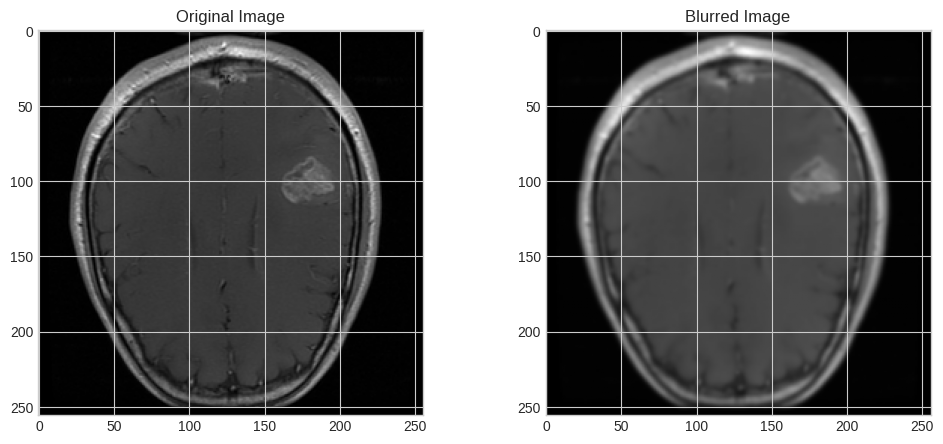

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].set_title("Original Image")
axes[0].imshow(tumor_slice, cmap='gray')
axes[1].set_title("Blurred Image")
axes[1].imshow(blurred, cmap='gray')
plt.show()